<a href="https://colab.research.google.com/github/julianschroeter/demo_semantic_analysis/blob/main/Student_Semantic_Analysis_Literary_Corpora_Demo_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semantic Analysis of Literary Corpora


## 1. What do we mean by “meaning”?

Philosophy, linguistics, and literary studies offer different answers:

| Level | A possible conception of meaning | Typical formalization |
|---|---|---|
| Word | concept, reference, lexical use | dictionary entry, semantic features |
| Sentence | propositional content and communicative force | logic, truth conditions, speech acts |
| Text | themes, structures, relations, <> | interpretation and explanation |
| Corpus | ??? | ??? |

Oliver R. Scholz warns against assuming that every text possesses one single, graspable “total meaning.” For corpus analysis, we therefore ask a more modest question:

> **Which observable aspect of meaning can we operationalize computationally?**

Distributional semantics answers:

> **Meaning can be approximated through patterns of contextual usage.**

## 2. From a real corpus to contexts

The following examples come from the **crime/suspense corpus of German dime novels**. Initially, imagine that we want to learn the meaning of the word **Detektiv** from German language use in general.

> Der **Detektiv** nahm gelassen sein Etui und brannte sich eine Zigarette an.  
> Der **Detektiv** jagte die Treppe hinauf.  
> Aufmerksam untersuchte der **Detektiv** jeden Winkel, durchstöberte Schrank und Schublade.  
> Der **Detektiv** überlegte.  
> „Nein“, erklärte der **Detektiv** mit Bestimmtheit.  
> Der **Detektiv** lächelte verschmitzt.  
> „Sie haben von Ihrer Waffe Gebrauch machen müssen?“, fragte der **Detektiv** die vier Polizisten.  
> „Keinesfalls, Herr Kommissar“, entgegnete der **Detektiv**.

### Student question

> Which recurring actions, objects, persons, or situations surround **Detektiv**?

## 3. How FastText learns a word vector

Our concrete models were trained with:

- **architecture:** Skip-gram (`sg=1`)
- **maximum context window:** 5 words to the left and 5 words to the right
- **vector dimensions:** 200

For an occurrence such as

> Der erfahrene **Detektiv** nahm gelassen sein Etui und brannte sich eine Zigarette an.

FastText generates many prediction tasks. In Skip-gram, the target word is used to predict nearby context words:

```text
Detektiv  →  erfahrene
Detektiv  →  nahm
Detektiv  →  gelassen
Detektiv  →  sein
Detektiv  →  Etui
```

The model begins with random numerical vectors. Whenever a predicted context word is wrong, optimization makes small changes to the vectors. Across millions of examples:

```text
corpus → context windows → prediction errors → vector updates → semantic geometry
```

Words that repeatedly predict similar contexts acquire similar vectors.

### What FastText adds

FastText also learns vectors for character fragments. This helps with German compounds and related forms such as *Detektiv*, *Privatdetektiv*, and *Detektivgeschichte*.

## 4. Load the two corpus-specific vector spaces

The models were trained separately on:

- **Romance:** `liebe`, `heimat`, `adel`, `erotik`
- **Crime/suspense:** `krimi`, `abenteuer`

The files are downloaded into Colab's temporary cloud runtime. Nothing is installed permanently on the students' laptops.

In [ ]:
!pip -q install "gensim>=4.3,<5" gdown requests ipywidgets scikit-learn

from pathlib import Path
import shutil
import requests
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

from gensim.models import KeyedVectors
from sklearn.decomposition import PCA
from matplotlib.patches import Arc
from IPython.display import display, Markdown, clear_output

ROMANCE_MODEL_URL = "https://drive.google.com/uc?id=1PK0i7yGp25vzLktHeEmdn1VwqsQy4zMf"
CRIME_MODEL_URL = "https://drive.google.com/uc?id=1bHi8tPw52myU5vVhGLdMkaidzTeXzAUs"

MODEL_DIR = Path("/content/heftroman_models")
MODEL_DIR.mkdir(exist_ok=True)


def looks_like_html(path):
    with path.open("rb") as f:
        start = f.read(512).lstrip().lower()
    return start.startswith(b"<") or b"<html" in start or b"<!doctype html" in start


def download_model(url, destination):
    if destination.exists() and destination.stat().st_size > 1024 and not looks_like_html(destination):
        print(f"Using existing {destination.name}")
        return
    destination.unlink(missing_ok=True)
    result = gdown.download(url=url, output=str(destination), quiet=False, fuzzy=True)
    if result is None or not destination.exists() or looks_like_html(destination):
        raise RuntimeError(f"Could not download a valid model file: {destination.name}")


def load_vectors(path):
    with path.open("rb") as f:
        magic = f.read(4)
    if magic[:2] == b"\x1f\x8b":
        return KeyedVectors.load_word2vec_format(str(path), binary=True)
    if magic[:1] == b"\x80":
        legacy = path.with_suffix("").with_suffix(".kv")
        shutil.copyfile(path, legacy)
        return KeyedVectors.load(str(legacy), mmap=None)
    if magic[:1].isdigit():
        raw = path.with_suffix("").with_suffix(".bin")
        shutil.copyfile(path, raw)
        return KeyedVectors.load_word2vec_format(str(raw), binary=True)
    raise RuntimeError(f"Unknown model format: {magic!r}")


romance_path = MODEL_DIR / "romance_student.bin.gz"
crime_path = MODEL_DIR / "crime_suspense_student.bin.gz"

download_model(ROMANCE_MODEL_URL, romance_path)
download_model(CRIME_MODEL_URL, crime_path)

romance = load_vectors(romance_path)
crime = load_vectors(crime_path)

print(f"Romance vocabulary:       {len(romance):,} words")
print(f"Crime/suspense vocabulary: {len(crime):,} words")
print(f"Vector dimensions:         {romance.vector_size}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 33.3 MB/s eta 0:00:00


Downloading...
From: https://drive.google.com/uc?id=1PK0i7yGp25vzLktHeEmdn1VwqsQy4zMf
To: /content/heftroman_models/romance_student.bin.gz
100%|██████████| 41.0M/41.0M [00:00<00:00, 68.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bHi8tPw52myU5vVhGLdMkaidzTeXzAUs
To: /content/heftroman_models/crime_suspense_student.bin.gz
100%|██████████| 12.1M/12.1M [00:00<00:00, 71.0MB/s]


Romance vocabulary:       50,000 words
Crime/suspense vocabulary: 16,177 words
Vector dimensions:         200


## 5. Look inside a word vector *(about 1 minute)*

A word embedding is literally an array of numbers. Change the word and corpus below.

The individual coordinates are **not** normally interpretable. Their relational geometry is what matters.

In [ ]:
model = crime
word = "detektiv"

vector = model[word]

print("Word:", word)
print("Python type:", type(vector))
print("Number of dimensions:", len(vector))
print("Shape:", vector.shape)
print("First 10 coordinates:")
print(vector[:10])

Word: detektiv
Python type: <class 'numpy.ndarray'>
Number of dimensions: 200
Shape: (200,)
First 10 coordinates:
[-0.13614629 -0.1893145   0.31538865 -0.10798479  0.35196784 -0.04391269
 -0.24041617  0.5361808  -0.09472848  0.19425602]


## 6. How do we measure semantic similarity?

Two words are considered similar when their vectors point in similar directions.

\[
\begin{aligned}
\text{cosine similarity}
    &= \cos(\alpha)
     = \frac{\mathbf{v}\cdot\mathbf{w}}
            {\|\mathbf{v}\|\,\|\mathbf{w}\|} \\
\text{cosine distance}
    &= 1-\cos(\alpha)
\end{aligned}
\]

- smaller angle → higher cosine similarity
- identical direction → similarity 1, distance 0
- approximately orthogonal directions → similarity 0, distance 1

The following plot simulates this geometry in two dimensions. The actual FastText vectors have 200 dimensions; PCA is used only for visualization.

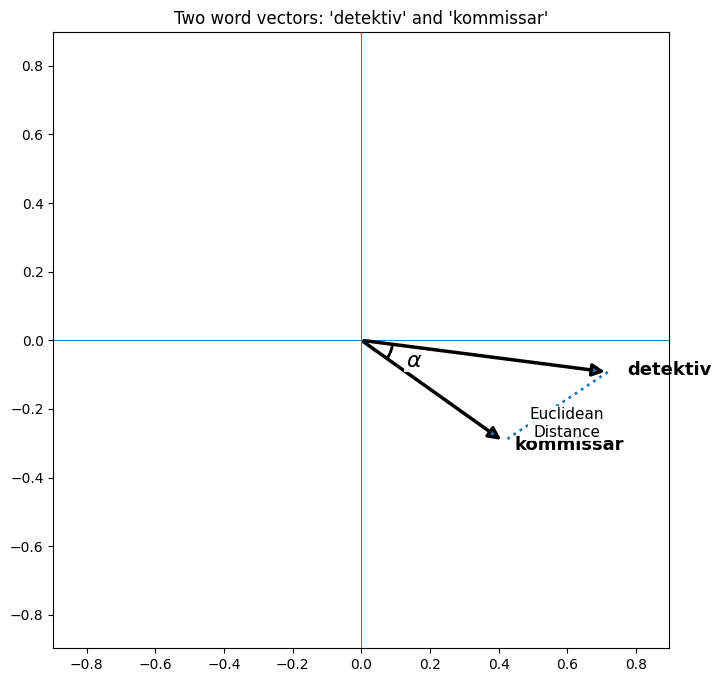

In [ ]:
def fit_embedding_pca(model, sample_size=20000, random_state=42):
    rng = np.random.default_rng(random_state)
    words = model.index_to_key
    indices = rng.choice(len(words), size=min(sample_size, len(words)), replace=False)
    vectors = np.vstack([model[words[i]] for i in indices])
    return PCA(n_components=2).fit(vectors)


def plot_word_vectors_pca(model, pca, word1, word2):
    word1, word2 = word1.lower().strip(), word2.lower().strip()
    if word1 not in model or word2 not in model:
        raise ValueError("Both words must occur in the model.")

    p1 = model[word1] @ pca.components_.T
    p2 = model[word2] @ pca.components_.T

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.axhline(0, linewidth=0.7)
    ax.axvline(0, linewidth=0.7)

    for point in (p1, p2):
        ax.annotate("", xy=point, xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", lw=2.5, mutation_scale=18))

    ax.text(*(p1 * 1.08), word1, fontsize=13, fontweight="bold")
    ax.text(*(p2 * 1.08), word2, fontsize=13, fontweight="bold")

    a1 = np.degrees(np.arctan2(p1[1], p1[0])) % 360
    a2 = np.degrees(np.arctan2(p2[1], p2[0])) % 360
    difference = (a2 - a1) % 360
    start, angle = (a1, difference) if difference <= 180 else (a2, 360 - difference)

    radius = 0.18 * min(np.linalg.norm(p1), np.linalg.norm(p2))
    ax.add_patch(Arc((0, 0), 2 * radius, 2 * radius,
                     theta1=start, theta2=start + angle, linewidth=2))

    middle = np.radians(start + angle / 2)
    label_radius = 1.8 * radius
    ax.text(label_radius * np.cos(middle), label_radius * np.sin(middle),
            r"$\alpha$", fontsize=16, ha="center", va="center",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1))

    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], linestyle=":", linewidth=2)
    midpoint = (p1 + p2) / 2
    normal = np.array([-(p2 - p1)[1], (p2 - p1)[0]])
    if np.linalg.norm(normal):
        normal /= np.linalg.norm(normal)
    label = midpoint + 0.08 * max(np.linalg.norm(p1), np.linalg.norm(p2)) * normal
    ax.text(*label, "Euclidean\nDistance", fontsize=11, ha="center", va="center",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1))

    extent = 1.25 * max(abs(p1).max(), abs(p2).max())
    ax.set(xlim=(-extent, extent), ylim=(-extent, extent), aspect="equal",
           title=f"Two word vectors: '{word1}' and '{word2}'")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.show()


crime_pca = fit_embedding_pca(crime)
plot_word_vectors_pca(crime, crime_pca, "detektiv", "kommissar")

## 7. From one word to two literary corpora

Now we return to the guiding question. The same word is queried in two independently trained vector spaces.

### Shared task

1. Start with **tod**.
2. Compare its ten nearest neighbors in romance and crime/suspense.
3. Identify one shared association and one genre-specific association.
4. Then choose another word yourselves.

Possible words: `liebe`, `familie`, `herz`, `angst`, `schuld`, `haus`, `nacht`, `frau`, `mann`.

In [ ]:
def nearest_table(word, n=10):
    word = word.strip().lower()
    rows = []
    for label, model in [("Romance", romance), ("Crime/suspense", crime)]:
        if word not in model:
            rows.append({"Corpus": label, "Rank": "–", "Neighbor": "not in vocabulary", "Similarity": np.nan})
            continue
        for rank, (neighbor, score) in enumerate(model.most_similar(word, topn=n), 1):
            rows.append({"Corpus": label, "Rank": rank, "Neighbor": neighbor, "Similarity": score})
    return pd.DataFrame(rows)


word_box = widgets.Text(value="tod", description="Word:", continuous_update=False)
number_slider = widgets.IntSlider(value=10, min=5, max=20, description="Neighbors:")
output = widgets.Output()


def update(_=None):
    with output:
        clear_output(wait=True)
        word = word_box.value.strip().lower()
        if not word:
            return
        display(Markdown(f"### Semantic neighborhood of **{word}**"))
        table = nearest_table(word, number_slider.value)
        display(table.style.hide(axis="index").format({"Similarity": lambda x: "" if pd.isna(x) else f"{x:.3f}"}))


word_box.observe(update, names="value")
number_slider.observe(update, names="value")
display(widgets.HBox([word_box, number_slider]), output)
update()

Output()

### Student activity: formulate one result

Complete this sentence:

> In the romance corpus, **________** is associated primarily with **________**, whereas in crime/suspense it is more strongly connected with **________**.

## 8. Reveal: what kind of “German” did the model learn?

Return to the initial **Detektiv** examples.

They did not represent German language in general. They came from a particular corpus:

> **German crime and adventure dime novels.**

The repeated contexts—investigation, questioning, weapons, police, rooms, cigarettes—are highly domain-specific.

Therefore:

```text
FastText does not learn a dictionary definition.
It learns the statistical organization of language in its training corpus.
```

This is precisely why embeddings are valuable for corpus analysis:

- a general-language model represents broad conventional usage;
- a literary-corpus model represents the semantic organization of a genre, period, publisher, author group, or discourse domain.

## 9. Synthesis and outlook

```text
literary corpus
      ↓
context windows
      ↓
millions of prediction tasks
      ↓
200-dimensional word vectors
      ↓
cosine similarity and nearest neighbors
      ↓
comparison of semantic organization across corpora
```

> **Word embeddings transform contextual patterns in a corpus into a geometric representation of meaning.**  
> Their power for Digital Humanities lies precisely in the fact that this geometry is **corpus-specific**.

### Next steps

- **Contextual embeddings:** one word occurrence can receive different vectors in different sentences.
- **Document embeddings:** passages or whole novels become vectors.
- **Semantic retrieval and RAG:** questions and documents are embedded so that relevant passages can be retrieved before an LLM generates an answer.

---
## Optional playground

In [ ]:
word1 = "detektiv"
word2 = "kommissar"
model = crime

print("Cosine similarity:", model.similarity(word1, word2))
print("Cosine distance:  ", model.distance(word1, word2))
print("Nearest neighbors:")
for neighbor, score in model.most_similar(word1, topn=5):
    print(f"{neighbor:20s} {score:.3f}")

Cosine similarity: 0.24288772
Cosine distance:   0.75711226
Nearest neighbors:
detektivs            0.943
detektive            0.839
privatdetektiv       0.814
hoteldetektiv        0.776
kriminalist          0.526
